# Stationarity, Decomposition, and Autocorrelation (Task 2-III to V)
Rolling statistics, ADF test, decomposition, ACF, and PACF.

In [7]:
# Imports and path setup
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "src").is_dir()), None)
if project_root is None:
    raise RuntimeError("Could not locate project root with 'src' directory")
sys.path.insert(0, str(project_root))

from src.utils.config import get_config
from src.data.preprocessing import load_city_parquet, get_top_square_id, get_area_series
from src.analysis.stationarity import rolling_statistics, adf_test
from src.analysis.decomposition import decompose_series
from src.analysis.anomaly_detection import anomaly_summary

cfg = get_config()

In [2]:
# Load parquet and select a target series (top-traffic square)
parquet_path = cfg.data_processed / "city_traffic.parquet"
city_df = load_city_parquet(parquet_path)
top_square = get_top_square_id(city_df)
series = get_area_series(city_df, top_square)
series.head()

time_interval
2013-10-31 23:00:00+00:00    379.972931
2013-10-31 23:10:00+00:00    371.122711
2013-10-31 23:20:00+00:00    429.297943
2013-10-31 23:30:00+00:00    350.184235
2013-10-31 23:40:00+00:00    268.586823
Name: internet_traffic, dtype: float32

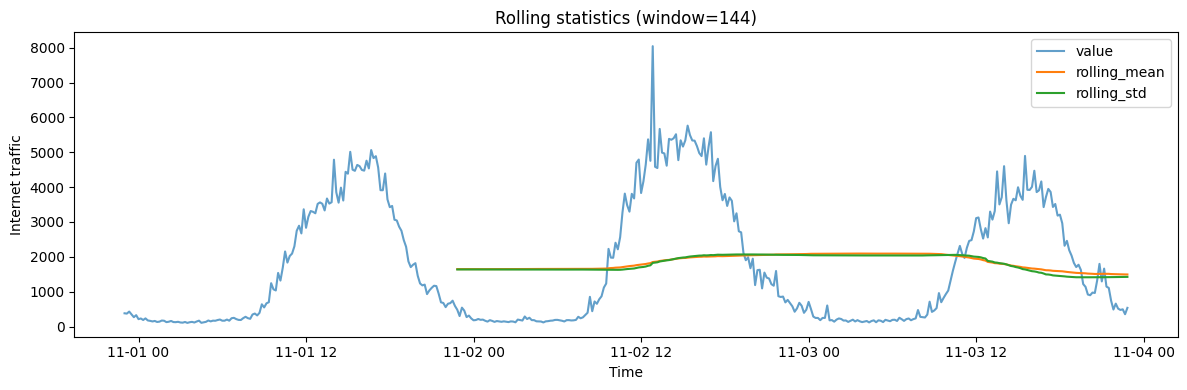

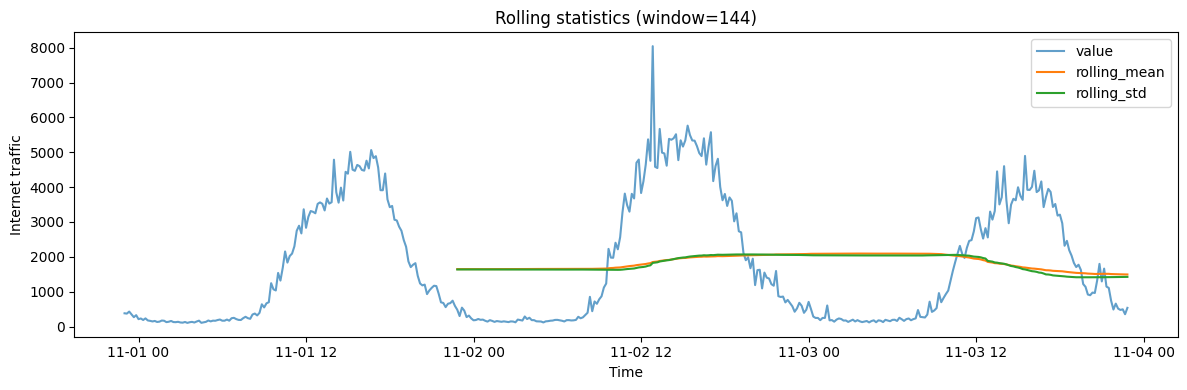

In [3]:
# Rolling mean and std (10-minute data, 144 points = 1 day)
roll = rolling_statistics(series, window=144)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll.index, roll["value"], label="value", alpha=0.7)
ax.plot(roll.index, roll["rolling_mean"], label="rolling_mean")
ax.plot(roll.index, roll["rolling_std"], label="rolling_std")
ax.set_title("Rolling statistics (window=144)")
ax.set_xlabel("Time")
ax.set_ylabel("Internet traffic")
ax.legend()
fig.tight_layout()
fig

In [4]:
# Augmented Dickey-Fuller test
adf_test(series)

AttributeError: 'numpy.float64' object has no attribute 'items'

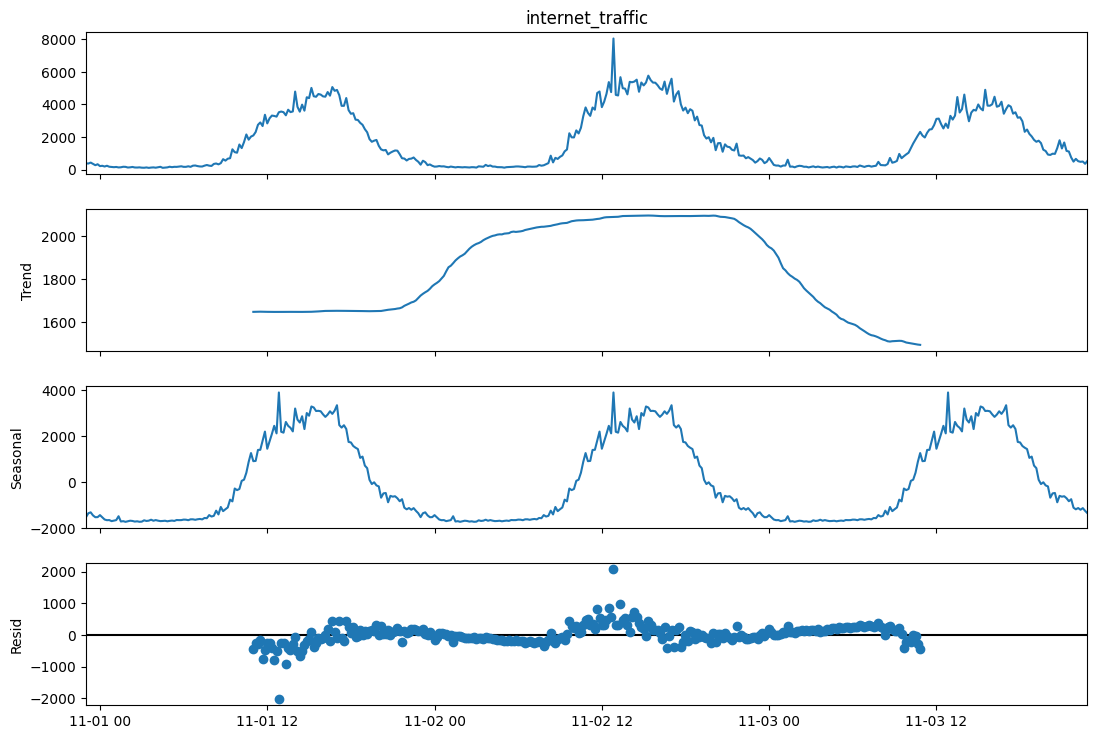

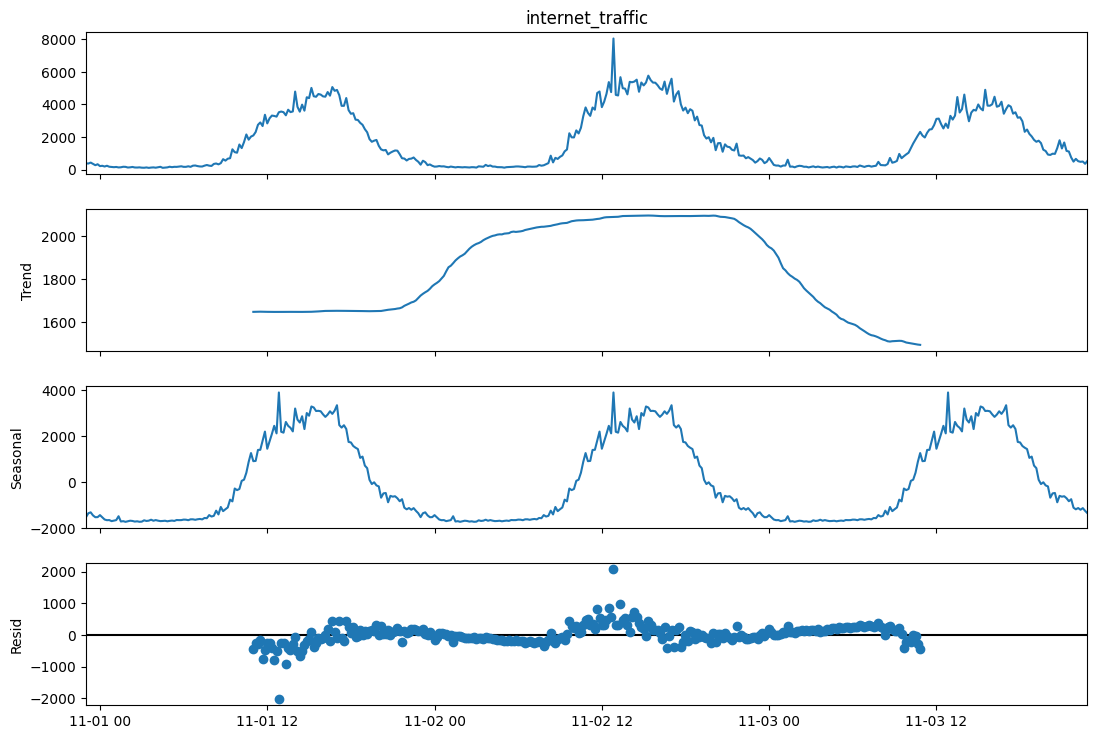

In [5]:
# Seasonal decomposition (daily periodicity: 144)
decomp = decompose_series(series, period=144, model="additive")
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig

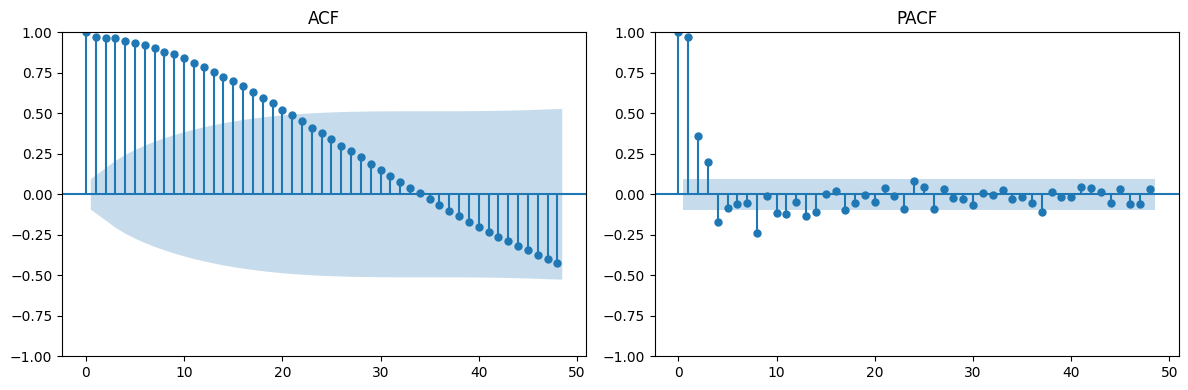

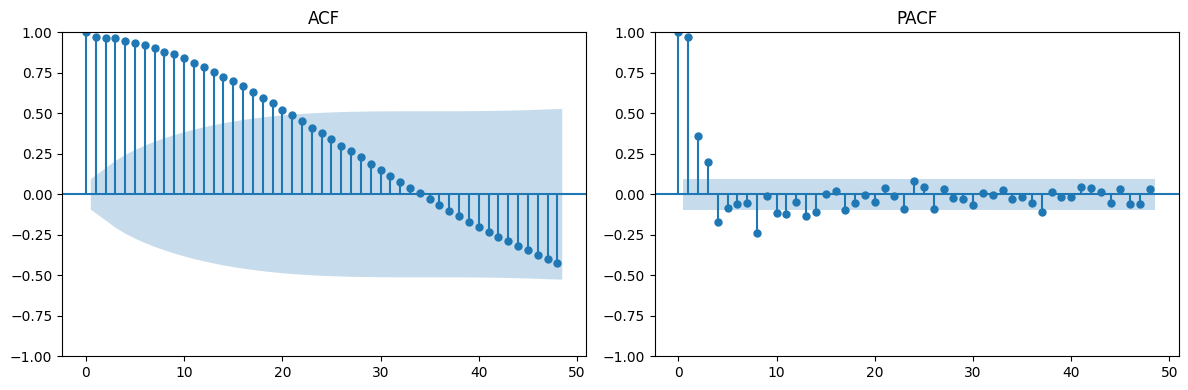

In [6]:
# Autocorrelation and partial autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series.dropna(), ax=axes[0], lags=48)
plot_pacf(series.dropna(), ax=axes[1], lags=48, method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
fig.tight_layout()
fig

In [ ]:
# Anomaly summary (z-score and IQR)
anomaly_summary(series)